In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
# titanic = sns.load_dataset("titanic")
# titanic = sns.load_dataset("titanic").dropna()
# print(titanic)
# print("Shape of titanic after dropna is :", titanic.shape)
# taxis = sns.load_dataset("taxis")
# countnatips = tips.isna().sum()
# countnatips = tips.isna().sum()
# countnatitanic = titanic.isna().sum()
# countnataxis = taxis.isna().sum()
# print("tips: \n", countnatips)
# print("titanic: \n", countnatitanic)
# print("taxis: \n", countnataxis)
penguins = sns.load_dataset("penguins").dropna()   # cleaned, as we learned in Lab 2
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female



## Which plot for which question? — cheat sheet

| Your question | Plot | Function |
|---|---|---|
| How is one numeric variable distributed? | histogram / KDE | `sns.histplot`, `sns.kdeplot` |
| Does it differ across groups? | grouped box / violin | `sns.boxplot`, `sns.violinplot` |
| How often does each category occur? | count plot | `sns.countplot` |
| What is the average X per group? | bar plot | `sns.barplot` |
| How do two numeric variables relate? | scatter (+ trend) | `sns.scatterplot`, `sns.regplot` |
| How does something change over time/order? | line plot | `sns.lineplot` |
| Which variables correlate? | heatmap of `corr()` | `sns.heatmap` |
| First overview of everything? | pair plot | `sns.pairplot` |
| Same plot for each subgroup? | panel grid | `sns.catplot` (`col=`) |

And the quality checklist for **every** figure in your report:

- [ ] title states what the plot shows (even better: states the *finding*)
- [ ] both axes labeled, with units
- [ ] legend present if colors/styles encode something
- [ ] readable font sizes; no overlapping labels
- [ ] one sentence of interpretation *below the figure* — a plot nobody explains is a plot nobody needed

<a id="13"></a>

## Task

All on the `penguins` dataset. For each plot, include title + axis labels, and write one sentence on what it shows.

**Exercise 1.** A histogram of `bill_length_mm` with a sensible number of bins. Is the distribution skewed? Could there be more than one bump — and why might that be?

**Exercise 2.** A scatter plot of `bill_length_mm` vs `bill_depth_mm`, colored by species. Do clusters appear?

**Exercise 3.** Grouped boxplots of `flipper_length_mm` per island. Which island hosts the biggest penguins? (Bonus: which species lives there? Check with `value_counts`.)

**Exercise 4.** A figure with **two subplots side by side**: left, a countplot of species; right, a barplot of mean `body_mass_g` per species. Use `plt.subplots(1, 2, ...)`.

**Exercise 5.** Save your favorite of the four as a PNG at `dpi=150` and download it from the Colab file panel.

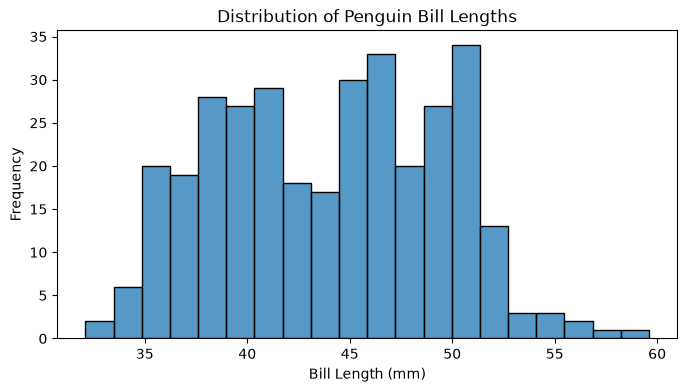

In [2]:
# Exercise 1
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=penguins, x="bill_length_mm", bins=20, ax=ax)
ax.set_title("Distribution of Penguin Bill Lengths")
ax.set_xlabel("Bill Length (mm)")
ax.set_ylabel("Frequency")
plt.show()

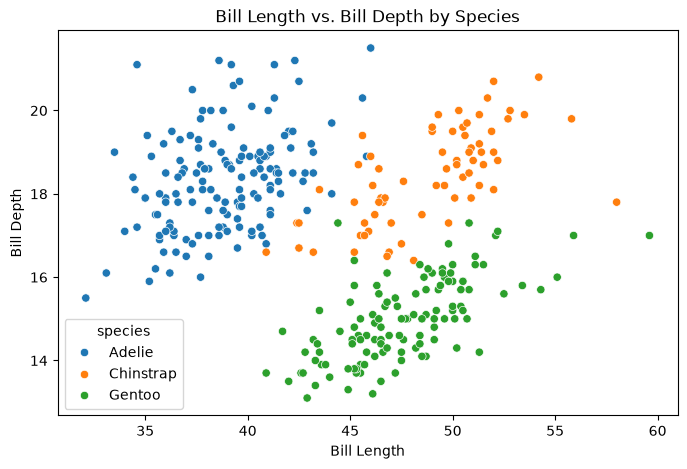

In [3]:
# Exercise 2
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", ax=ax)
ax.set_title("Bill Length vs. Bill Depth by Species")
ax.set_xlabel("Bill Length")
ax.set_ylabel("Bill Depth")
plt.show()

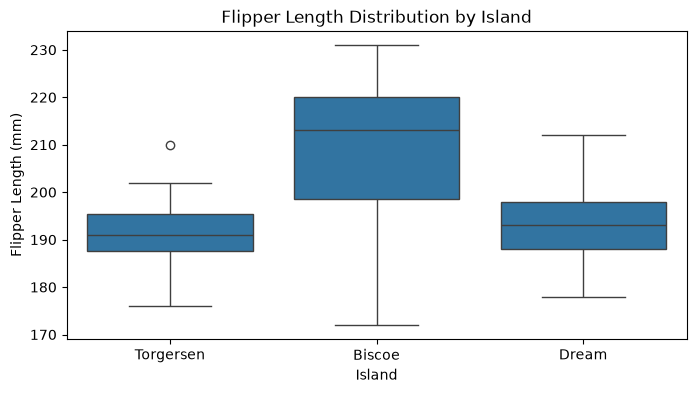

species
Gentoo    119
Adelie     44
Name: count, dtype: int64


In [4]:
# Exercise 3

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=penguins, x="island", y="flipper_length_mm", ax=ax)
ax.set_title("Flipper Length Distribution by Island")
ax.set_xlabel("Island")
ax.set_ylabel("Flipper Length (mm)")
plt.show()


biscoe_penguins = penguins[penguins["island"] == "Biscoe"]
print(biscoe_penguins["species"].value_counts())

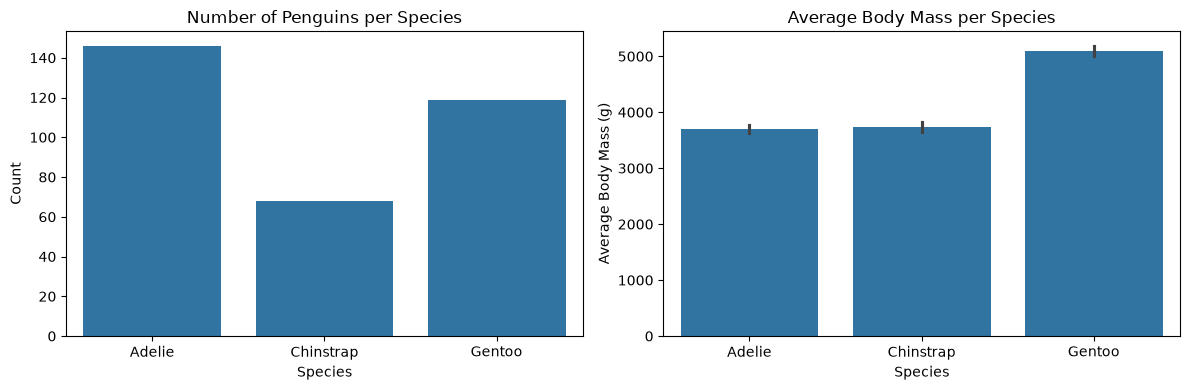

In [5]:
# Exercise 4
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=penguins, x="species", ax=axes[0])
axes[0].set_title("Number of Penguins per Species")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Count")

sns.barplot(data=penguins, x="species", y="body_mass_g", estimator="mean", ax=axes[1])
axes[1].set_title("Average Body Mass per Species")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Average Body Mass (g)")

fig.tight_layout()
plt.show()

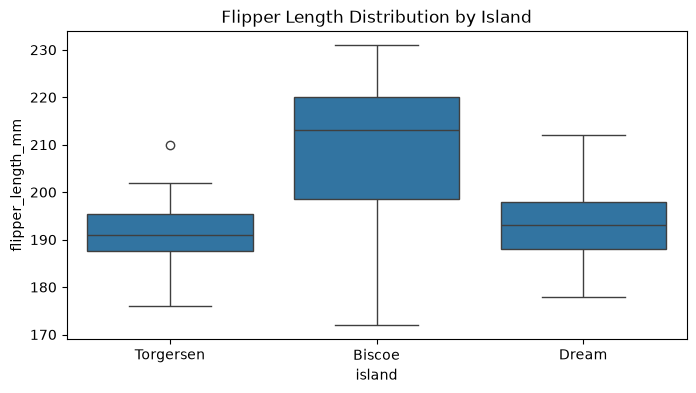

In [6]:
# Exercise 5
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=penguins, x="island", y="flipper_length_mm", ax=ax)
ax.set_title("Flipper Length Distribution by Island")

fig.savefig("island_penguins.png", dpi=150, bbox_inches="tight")
plt.show()